In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error,
)
from catboost import CatBoostRegressor
import xgboost as xgb
import lightgbm as lgb

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "synthetic_task_time_data.csv"  # update if needed

df = pd.read_csv(DATA_PATH, parse_dates=["Task_Date"])
df = df.sort_values("Task_Date").reset_index(drop=True)

df["month"] = df["Task_Date"].dt.month
df["day_of_week"] = df["Task_Date"].dt.dayofweek

DROP_COLUMNS = ["Task_ID", "Task_Date", "Machine_ID", "Operator_ID", "Actual_Time_min"]
X = df.drop(columns=DROP_COLUMNS)
y = df["Actual_Time_min"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['Task_Type', 'Material_Type', 'Ground_Condition', 'Weather', 'Operator_Skill', 'Machine_Condition', 'Breakdown_Occurred']
Numeric: ['Task_Area_sqm', 'Ground_Slope_deg', 'Site_Distance_km', 'Temperature_C', 'Crew_Size', 'Operator_Experience_Months', 'Machine_Age_yrs', 'Permit_Setup_Delay_min', 'Estimated_Time_min', 'month', 'day_of_week']


In [3]:
n = len(X)
train_end, val_end = int(n * 0.70), int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Actual_Time_min stats (train):")
print(y_train.describe())

Train: (5600, 18)  Val: (1200, 18)  Test: (1200, 18)
Actual_Time_min stats (train):
count    5600.000000
mean      306.219696
std       198.285459
min        28.200000
25%       161.800000
50%       259.300000
75%       399.250000
max      1398.300000
Name: Actual_Time_min, dtype: float64


In [4]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return rmse, mae, r2, mape

In [5]:
candidates = {}

lin_pipe = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lin_pipe.fit(X_train, y_train)
candidates["LinearRegression"] = (lin_pipe, False)

ridge_pipe = Pipeline([("prep", preprocessor), ("reg", Ridge(alpha=5.0))])
ridge_pipe.fit(X_train, y_train)
candidates["Ridge"] = (ridge_pipe, False)

loglin_pipe = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
loglin_pipe.fit(X_train, np.log1p(y_train))
candidates["LogLinearRegression"] = (loglin_pipe, True)

rf_pipe = Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(
    n_estimators=500, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
candidates["RandomForest"] = (rf_pipe, False)

gbr_pipe = Pipeline([("prep", preprocessor), ("reg", GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42))])
gbr_pipe.fit(X_train, y_train)
candidates["GradientBoosting"] = (gbr_pipe, False)

xgb_pipe = Pipeline([("prep", preprocessor), ("reg", xgb.XGBRegressor(
    n_estimators=800, learning_rate=0.04, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=5, random_state=42))])
xgb_pipe.fit(X_train, y_train)
candidates["XGBoost"] = (xgb_pipe, False)

lgb_pipe = Pipeline([("prep", preprocessor), ("reg", lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.04, max_depth=5, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=5, random_state=42, verbose=-1))])
lgb_pipe.fit(X_train, y_train)
candidates["LightGBM"] = (lgb_pipe, False)

cb = CatBoostRegressor(
    loss_function="RMSE", iterations=1500, learning_rate=0.04, depth=6,
    l2_leaf_reg=6, random_seed=42, od_type="Iter", od_wait=100,
    verbose=0, allow_writing_files=False,
)
cb.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_val, y_val), verbose=0)
candidates["CatBoost"] = (cb, False)


def predict(model, is_log, X_):
    pred = model.predict(X_)
    return np.expm1(pred) if is_log else pred

In [6]:
print(f"{'Model':<20}{'Val RMSE':<12}{'Val MAE':<12}{'Val R2':<10}{'Val MAPE':<10}")
for name, (model, is_log) in candidates.items():
    pred = predict(model, is_log, X_val)
    rmse, mae, r2, mape = regression_metrics(y_val, pred)
    print(f"{name:<20}{rmse:<12.2f}{mae:<12.2f}{r2:<10.4f}{mape:<10.4f}")

print(f"\n{'Model':<20}{'Test RMSE':<12}{'Test MAE':<12}{'Test R2':<10}{'Test MAPE':<10}")
test_rmse = {}
for name, (model, is_log) in candidates.items():
    pred = predict(model, is_log, X_test)
    rmse, mae, r2, mape = regression_metrics(y_test, pred)
    test_rmse[name] = rmse
    print(f"{name:<20}{rmse:<12.2f}{mae:<12.2f}{r2:<10.4f}{mape:<10.4f}")

best_model_name = min(test_rmse, key=test_rmse.get)
best_model, best_is_log = candidates[best_model_name]
print(f"\nBest model on test set (lowest RMSE): {best_model_name}")

Model               Val RMSE    Val MAE     Val R2    Val MAPE  
LinearRegression    49.50       34.17       0.9375    0.1685    
Ridge               49.48       34.11       0.9376    0.1679    
LogLinearRegression 62.71       39.18       0.8998    0.1375    
RandomForest        48.67       31.39       0.9396    0.1055    
GradientBoosting    29.72       18.47       0.9775    0.0664    
XGBoost             27.68       17.81       0.9805    0.0590    
LightGBM            28.49       18.02       0.9793    0.0593    
CatBoost            25.65       16.31       0.9832    0.0545    

Model               Test RMSE   Test MAE    Test R2   Test MAPE 
LinearRegression    51.05       35.89       0.9371    0.1821    
Ridge               51.03       35.84       0.9372    0.1814    
LogLinearRegression 59.10       38.51       0.9157    0.1411    
RandomForest        48.41       33.15       0.9434    0.1130    
GradientBoosting    28.82       19.21       0.9799    0.0718    
XGBoost             28.0

In [7]:
test_pred = predict(best_model, best_is_log, X_test)
rmse, mae, r2, mape = regression_metrics(y_test, test_pred)
print(f"Final test RMSE: {rmse:.2f} min")
print(f"Final test MAE:  {mae:.2f} min")
print(f"Final test R2:   {r2:.4f}")
print(f"Final test MAPE: {mape:.2%}")

Final test RMSE: 24.92 min
Final test MAE:  16.49 min
Final test R2:   0.9850
Final test MAPE: 5.89%


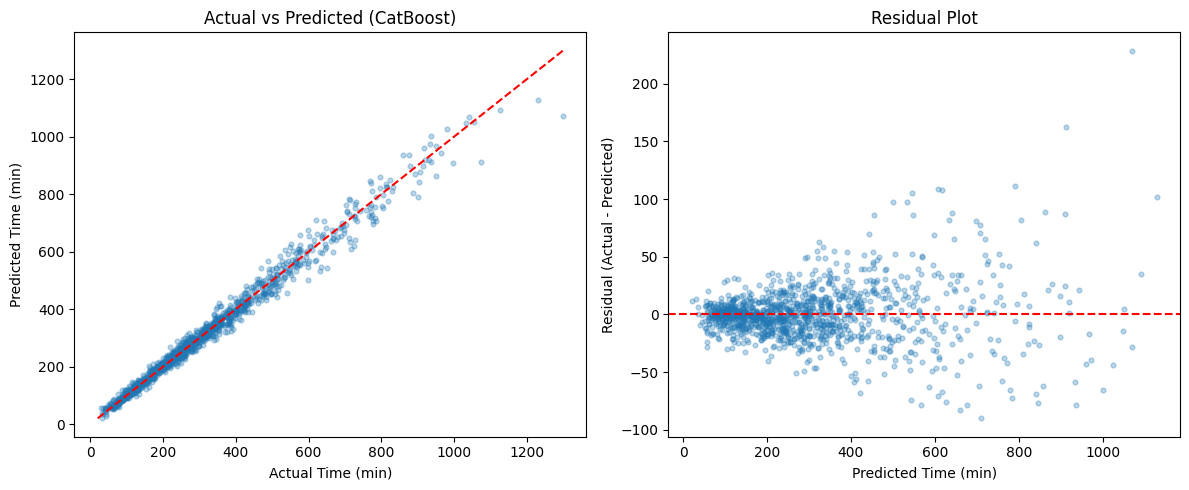

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, test_pred, alpha=0.3, s=12)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[0].plot(lims, lims, "--", color="red")
axes[0].set_xlabel("Actual Time (min)")
axes[0].set_ylabel("Predicted Time (min)")
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")

residuals = y_test.values - test_pred
axes[1].scatter(test_pred, residuals, alpha=0.3, s=12)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Time (min)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("regression_evaluation.png", dpi=120)
plt.show()

In [9]:
if best_model_name == "CatBoost":
    importances = pd.Series(best_model.get_feature_importance(), index=X.columns).sort_values(ascending=False)
    print("Top drivers of Actual_Time_min (CatBoost feature importance):")
    print(importances.head(12))
elif best_model_name in ("LinearRegression", "Ridge", "LogLinearRegression"):
    reg = best_model.named_steps["reg"]
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
    coefs = pd.Series(reg.coef_, index=feature_names).sort_values(key=abs, ascending=False)
    print("Top drivers (standardized coefficients):")
    print(coefs.head(12))
else:
    reg = best_model.named_steps["reg"]
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
    importances = pd.Series(reg.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"Top drivers ({best_model_name} feature importance):")
    print(importances.head(12))

Top drivers of Actual_Time_min (CatBoost feature importance):
Estimated_Time_min            63.874527
Operator_Skill                 8.939379
Operator_Experience_Months     4.954327
Material_Type                  4.887300
Ground_Condition               3.901287
Task_Area_sqm                  2.670367
Weather                        2.009108
Site_Distance_km               1.818481
Machine_Age_yrs                1.367403
Machine_Condition              1.253934
Crew_Size                      1.168636
Breakdown_Occurred             1.038066
dtype: float64


In [10]:
if best_model_name == "CatBoost":
    best_model.save_model("best_time_model.cbm")
    print("Saved CatBoost model to best_time_model.cbm")
else:
    joblib.dump(best_model, "best_time_model.joblib")
    print(f"Saved {best_model_name} pipeline to best_time_model.joblib")

Saved CatBoost model to best_time_model.cbm


In [11]:
def predict_task_time(row_dict, model=best_model, is_log=best_is_log):
    """
    row_dict: dict of raw feature values matching X.columns
    (Estimated_Time_min, Task_Type, Weather, Operator_Skill, Machine_Age_yrs,
    plus the additional fields this notebook added).
    Returns predicted Actual_Time_min in minutes.
    """
    row_df = pd.DataFrame([row_dict])[X.columns]
    pred = model.predict(row_df)[0]
    return float(np.expm1(pred)) if is_log else float(pred)


example = X_test.iloc[0].to_dict()
pred_time = predict_task_time(example)
print(f"Example -> predicted: {pred_time:.1f} min, actual: {y_test.iloc[0]:.1f} min, "
      f"estimated (baseline): {example['Estimated_Time_min']:.1f} min")

Example -> predicted: 100.3 min, actual: 104.8 min, estimated (baseline): 84.7 min
